<a href="https://colab.research.google.com/github/ahmer-talal/AI-Labs/blob/main/HillClimb_Algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting route: [7, 9, 4, 8, 3, 0, 5, 6, 1, 2]
Initial cost (distance): 406.90



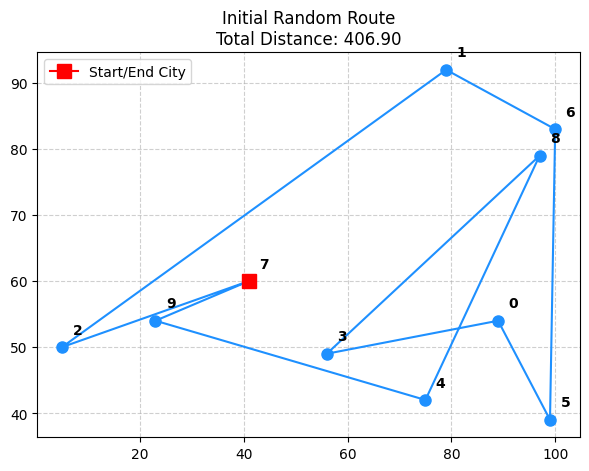

Starting Hill Climbing optimization...

Found a better route! New distance: 405.26
Found a better route! New distance: 381.27
Found a better route! New distance: 312.59
Found a better route! New distance: 312.30
Found a better route! New distance: 311.79
Found a better route! New distance: 297.10
Found a better route! New distance: 262.71
Found a better route! New distance: 254.66

Final optimized route: [7, 1, 6, 8, 0, 5, 4, 3, 2, 9]
Final cost (distance): 254.66


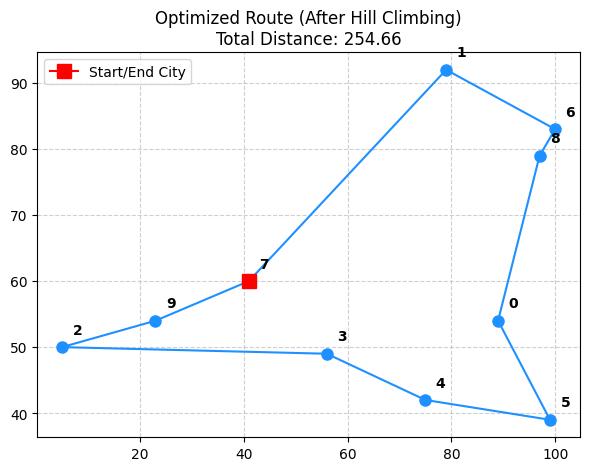

In [3]:
import random
import math
import matplotlib.pyplot as plt

num_cities = 10

# Generate random (x, y) coordinates for 10 cities to plot them on graph
cities = [(random.randint(0, 100), random.randint(0, 100)) for _ in range(num_cities)]

def get_distance(city1, city2):
    # Calculate Euclidean distance between two cities
    return math.sqrt((city1[0] - city2[0])**2 + (city1[1] - city2[1])**2)

def calculate_route_cost(route):
    # Calculate the total distance of a given route
    total_dist = 0
    for i in range(len(route)):
        from_city = cities[route[i]]
        # Use modulo to loop back to the first city at the end of the trip
        to_city = cities[route[(i + 1) % len(route)]]
        total_dist += get_distance(from_city, to_city)
    return total_dist

def plot_route(route, title):
    # Extract X and Y coordinates in the exact order of the route
    x = [cities[i][0] for i in route]
    y = [cities[i][1] for i in route]

    # Connect the last city back to the first one to close the loop
    x.append(x[0])
    y.append(y[0])

    plt.figure(figsize=(7, 5))
    plt.plot(x, y, marker='o', linestyle='-', color='dodgerblue', markersize=8)

    # Highlight the starting city with a red square
    plt.plot(x[0], y[0], marker='s', color='red', markersize=10, label="Start/End City")

    # Add city numbers next to the dots so we know which city is which
    for i in route:
        plt.text(cities[i][0] + 2, cities[i][1] + 2, str(i), fontsize=10, fontweight='bold')

    plt.title(f"{title}\nTotal Distance: {calculate_route_cost(route):.2f}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

#  Main Hill Climbing Algorithm
if __name__ == "__main__":

    # Start with a completely random route (shuffled list of numbers 0 to 9)
    current_route = list(range(num_cities))
    random.shuffle(current_route)
    current_cost = calculate_route_cost(current_route)

    print(f"Starting route: {current_route}")
    print(f"Initial cost (distance): {current_cost:.2f}\n")

    # Visualize the initial, messy random path
    plot_route(current_route, "Initial Random Route")

    print("Starting Hill Climbing optimization...\n")

    # Try to improve the route 1000 times
    for i in range(1000):
        # Create a copy of current route to test out changes
        new_route = current_route.copy()

        # Pick two random cities and swap their order in the route
        city_a, city_b = random.sample(range(num_cities), 2)
        new_route[city_a], new_route[city_b] = new_route[city_b], new_route[city_a]

        new_cost = calculate_route_cost(new_route)

        # If the new swapped route is shorter, keep it as our new best!
        if new_cost < current_cost:
            current_route = new_route
            current_cost = new_cost
            print(f"Found a better route! New distance: {current_cost:.2f}")

    print(f"\nFinal optimized route: {current_route}")
    print(f"Final cost (distance): {current_cost:.2f}")

    # Visualize the final, optimized path
    plot_route(current_route, "Optimized Route (After Hill Climbing)")